# Aliasing

In diesem Aufgabenblatt soll der sog. Aliasing-Effekt beobachtet werden. Hierfür ist ein Signal zu generieren, dessen Oberwellen die Nyquist-Frequenz zwangsläufig überschreiten. Untersuche unter anderem den Einfluss der optionalen Überabtastung des zu generierenden Signals.

In [14]:
import matplotlib.pyplot as plot
import numpy as np
import scipy.signal as signal

from dhbw import dasp
from qdft import QDFT

## Funktionsbasis

**Oscillator**

`Oscillator` ist die Basisklasse für künftige Spezialisierungen und repräsentiert einen komplexen Drehzeiger oder Phasor $\underline{p}$. Dieser ist wie folgt iterativ je Abtastwert zu berechnen:

$\underline{p}[n] = \underline{p}[n-1] \cdot e^{j\omega}$

Variable $\omega$ ist die normierte Kreisfrequenz gemäß:

$\omega = \frac{2 \pi f}{f_{SR}}$

Die initiale Frequenz $f$ kann sich im Verlauf der Signalgenerierung beliebig ändern, was im Funktionsaufruf `call` zu berücksichtigen gilt.

**Aufgabe:** Vervollständige die Funktion `call`.

In [15]:
class Oscillator:
    """
    Complex harmonic oscillator cos(phi) + 1j * sin(phi).
    """

    phasor = 1

    def __init__(self, frequency, samplerate):

        self.frequency = frequency
        self.samplerate = samplerate

    def __call__(self, frequency=None):

        phasor = self.phasor
        omega = 2 * np.pi * (frequency or self.frequency) / self.samplerate

        self.phasor = # TODO: compute the next phasor value

        return phasor

**LFO**

Die Spezialisierung `LFO` dient dazu, einen niederfrequenten **Sinusoid mit Amplitude zwischen 0 und 1** zu erzeugen. Auf diese Weise normierte Amplitude lässt sich im späteren Rechenschritt leichter auf den gewünschten Wertebereich skalieren.

**Aufgabe:** Vervollständige die Funktion `call`.

In [16]:
class LFO(Oscillator):
    """
    Sinusoidal wave with amplitude range [0..1].
    """

    def __call__(self, frequency=None):

        phasor = super().__call__(frequency)

        return # TODO: return current sinusoid amplitude in range [0..1]

**OSC**

Die Spezialisierung `OSC` hat den Apsruch eine "perfekte" Welle zu erzeugen. Über Parameter `shape` lässt sich die Gestalt dieser Welle variieren. Details dazu findest du im Artikel [Designing a Pleasing Sound Mathematically](https://www.jstor.org/stable/2690622).

**Aliasing:** Je nach `shape`-Wert zwischen 0 und 1 beinhaltet die generierte Welle mehr oder weniger ausgeprägte Oberwellen und ist somit anfällig für Aliasing.

In [17]:
class OSC(Oscillator):
    """
    The almost perfect wave, where each overtone
    amplitude is just half of the previous one.

    Designing a Pleasing Sound Mathematically
    https://www.jstor.org/stable/2690622
    """

    def __init__(self, frequency, samplerate, shape=0.5):

        super().__init__(frequency, samplerate)

        self.shape = shape

    def __call__(self, frequency=None, shape=None):

        phasor = super().__call__(frequency)

        sin = np.imag(phasor)
        cos = np.real(phasor)

        shape = (shape or self.shape)

        return sin / (1 + (shape*shape) - (shape+shape) * cos)

**SAW**

Die Spezialisierung `SAW` erzeugt eine [Sägezahnwelle](https://en.wikipedia.org/wiki/Sawtooth_wave).

**Aliasing:** Die Sägezahnwelle beinhaltet reichlich Oberwellen und ist somit extrem anfällig für Aliasing. Über Parameter `smooth` lässt sich eine optionale Signalkantenglättung gemäß [Antialiasing Oscillators in Subtractive Synthesis](https://ieeexplore.ieee.org/document/4117934) aktivieren, wodurch eine Tiefpasswirkung zustande kommt und die Oberwellen oberhalb der Nyquistfrequenz gedämpft werden.

In [18]:
class SAW(Oscillator):
    """
    Sawtooth wave, either naive (aliased) or smoothed (antialiased).

    https://en.wikipedia.org/wiki/Sawtooth_wave

    Antialiasing Oscillators in Subtractive Synthesis
    https://ieeexplore.ieee.org/document/4117934

    Phaseshaping Oscillator Algorithms for Musical Sound Synthesis
    https://core.ac.uk/download/pdf/297014559.pdf
    http://research.spa.aalto.fi/publications/papers/smc2010-phaseshaping

    PolyBLEP Oscillators
    https://www.kvraudio.com/forum/viewtopic.php?t=375517
    """

    t = 0

    def __init__(self, frequency, samplerate, smooth=True):

        super().__init__(frequency, samplerate)

        self.smooth = smooth

    def __call__(self, frequency=None, smooth=None):

        t = self.t
        dt = (frequency or self.frequency) / self.samplerate

        self.t = (t + dt) % 1

        smooth = (smooth or self.smooth)

        return (2 * t - 1) - (self.polyblep(t, dt) if smooth else 0)

    @staticmethod
    def polyblep(t, dt):

        assert 0 <=  t <= 1
        assert 0 <= dt <= 1

        if t < dt:
            t = t / dt
            return t+t - t*t - 1
        elif t > 1 - dt:
            t = (t - 1) / dt
            return t+t + t*t + 1
        else:
            return 0

**spectrogram**

Die Hilfsfunktion `spectrogram` visualisiert die detektierten Frequenzanteile des Eingangssignals `samples` entlang der Zeitachse. Dabei wird eine besondere Art der spektralen Signalanalyse gemäß [Sliding with a Constant Q](https://www.dafx.de/paper-archive/2008/papers/dafx08_63.pdf) eingesetzt.

In [19]:
def spectrogram(samples, samplerate):

    bandwidth = (50, samplerate/2)

    qdft = QDFT(samplerate, bandwidth)

    dft = qdft.qdft(np.concatenate((
        np.zeros(samplerate//2),
        samples,
        np.zeros(samplerate))))

    with np.errstate(divide='ignore'):
        dbfs = 20 * np.log10(np.abs(dft))
        dbfs[np.isinf(dbfs)] = -120

    roi = (-0.5, 1 + samples.size / samplerate, 0, 1)

    args = dict(extent=roi,
                origin='lower',
                aspect='auto',
                cmap='inferno',
                interpolation='nearest')

    plot.imshow(dbfs.T, **args)
    plot.clim(-120, 0)

    freqs = qdft.frequencies
    ticks = np.linspace(0, 1, freqs.size, endpoint=True)
    formatter = lambda tick, _: np.interp(tick, ticks, freqs).astype(int)
    plot.gca().yaxis.set_major_formatter(formatter)

    plot.xlabel('s')
    plot.ylabel('Hz')

    cbar = plot.colorbar()
    cbar.set_label('dB')

## Hauptprogramm

**Aufgabe:** Erzeuge unterschiedliche Signalarten und untersuche visuell sowie akustisch den Aliasing-Effekt. Aktiviere außerdem die Überabtastung über den positiven ganzzahligen Parameter `q`.

In [20]:
q = 1           # oversampling factor >=1
sr = 44100 * q  # sample rate in hertz
n = 5           # signal duration in seconds

In [21]:
oscillators = [
    OSC(440, sr, shape=0),       # perfect sine
    OSC(440, sr, shape=0.5),     # saw like
    OSC(440, sr, shape=0.9),     # distorted sine
    SAW(440, sr, smooth=True),   # smooth saw
    SAW(440, sr, smooth=False),  # naive saw
]

osc = oscillators[0]  # pick an osc of your choice

In [22]:
lfo, roi  = LFO(2 / n, sr), (100, 10000)  # define lfo to affect the signal frequency over time

In [23]:
# build the signal x as osc(lfo)
f = np.array([lfo() * np.ptp(roi) + np.amin(roi) for _ in range(n * sr)])
x = np.array([osc(_) for _ in f])

Funktion [decimate](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.decimate.html) wendet Anti-Aliasing-Filter (Tiefpass) an und führt anschließend die Unterabtastung um Faktor `q` durch.

In [24]:
# downsample and normalize the signal
sr = sr // q
x = signal.decimate(x, q) if q > 1 else x
x = 0.5 * x / np.abs(x).max()

**Beachte:** Reduziere die Lautstärke vor dem Anhören, da es insb. bei hohen Frequenzpassagen ziemlich laut wird.

In [25]:
dasp.io.display(x, sr=sr)

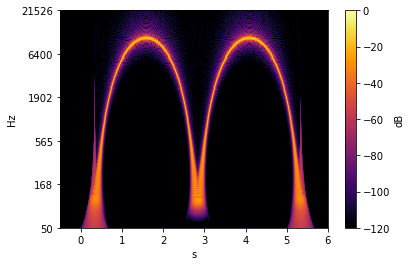

In [26]:
spectrogram(x, sr)